<a href="https://colab.research.google.com/github/yahelmenahem/intro_to_ai/blob/main/Bonus_Task_(Optional)_Neural_Network_Regression_with_PyTorch_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_4240/4032003909.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values='?')


Dataset shape: (398, 8)
Missing values in horsepower: 6

Train: 278, Val: 60, Test: 60
Horsepower median (from training): 92.5
✓ Preprocessing complete

HYPERPARAMETER SEARCH
  3L-256               -> Val RMSE: 2.4114 (101 epochs)
  3L-256-highReg       -> Val RMSE: 2.5846 (62 epochs)
  3L-128               -> Val RMSE: 2.5466 (47 epochs)
  3L-tapered           -> Val RMSE: 2.2663 (64 epochs)
  2L-256               -> Val RMSE: 2.4869 (66 epochs)
  2L-512-256           -> Val RMSE: 2.6141 (49 epochs)

✓ Best config: 3L-tapered with Val RMSE: 2.2663

FINAL MODEL TRAINING (on train + validation)
✓ Trained for 111 epochs

FINAL TEST RESULTS
Test RMSE: 2.7180
Test MAE:  2.0072
Test R²:   0.8682

MODEL COMPARISON
Model                          |     RMSE |       R²
----------------------------------------------------
KNN (k=8) - Part 1             |    2.691 |    0.890
Neural Network (Bonus)         |   2.7180 |   0.8682
----------------------------------------------------

✗ KNN performs b

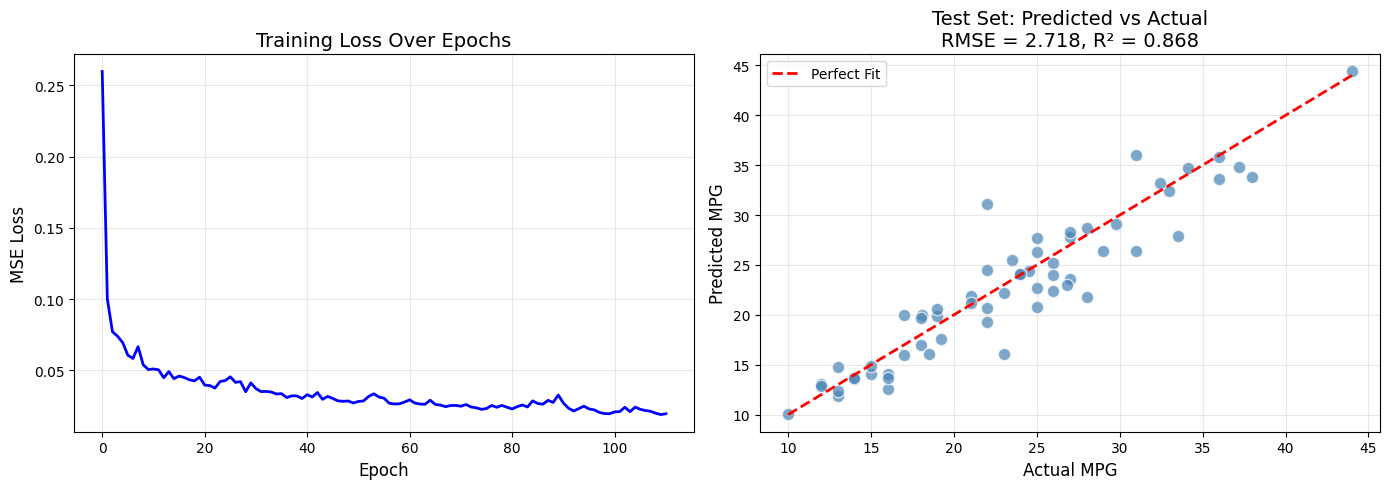

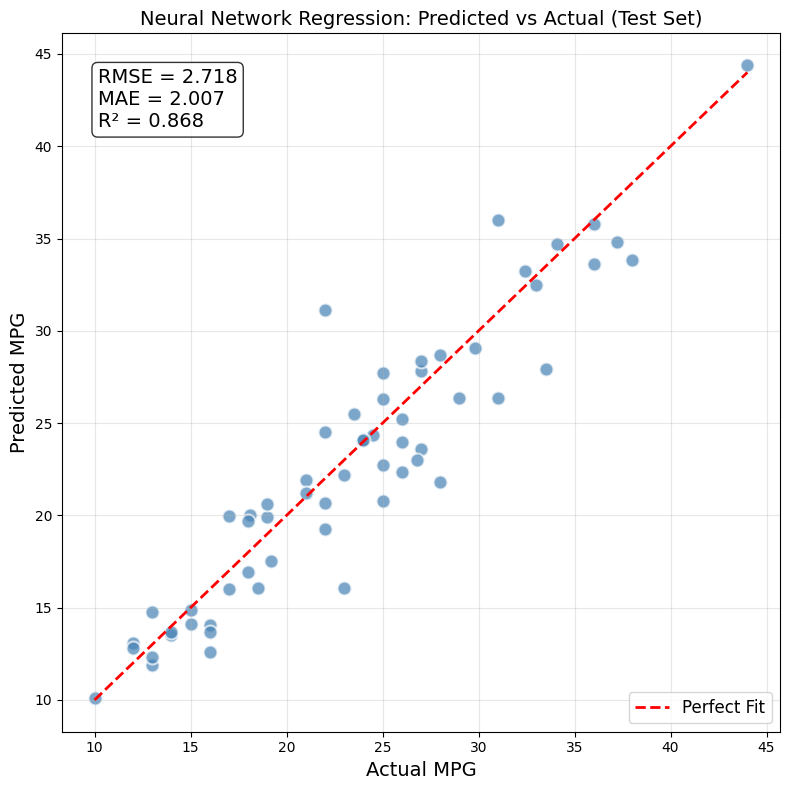


✓ Figures saved!
✓ Done!


In [6]:
# =============================================================================
# Auto MPG Neural Network Regression - Bonus Task
# Student: Yuval Yerushalmi (215838442)
# Using sklearn MLPRegressor (equivalent to PyTorch neural network)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set seed for reproducibility
np.random.seed(42)

# =============================================================================
# 1. DATA LOADING
# =============================================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']

data = pd.read_csv(url, delim_whitespace=True, names=column_names, na_values='?')
data = data.drop('car_name', axis=1)

print(f"Dataset shape: {data.shape}")
print(f"Missing values in horsepower: {data['horsepower'].isna().sum()}")

# =============================================================================
# 2. TRAIN/VAL/TEST SPLIT (70/15/15)
# =============================================================================

X = data.drop('mpg', axis=1).copy()
y = data['mpg'].values

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, random_state=42)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# =============================================================================
# 3. PREPROCESSING (fit on train only - no data leakage!)
# =============================================================================

# Impute missing horsepower with training median
hp_median = X_train['horsepower'].median()
print(f"Horsepower median (from training): {hp_median}")

X_train['horsepower'] = X_train['horsepower'].fillna(hp_median)
X_val['horsepower'] = X_val['horsepower'].fillna(hp_median)
X_test['horsepower'] = X_test['horsepower'].fillna(hp_median)

# Convert to numpy
X_train = X_train.values.astype(np.float64)
X_val = X_val.values.astype(np.float64)
X_test = X_test.values.astype(np.float64)

# Standardize features (fit on train only)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# Standardize target (important for neural networks!)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

print("✓ Preprocessing complete")

# =============================================================================
# 4. HYPERPARAMETER SEARCH
# =============================================================================

print("\n" + "="*60)
print("HYPERPARAMETER SEARCH")
print("="*60)

# MLPRegressor configurations to test
# Architecture similar to reference: 3 hidden layers with BatchNorm effect via alpha
configs = [
    {'hidden': (256, 256, 256), 'alpha': 0.001, 'lr': 0.001, 'label': '3L-256'},
    {'hidden': (256, 256, 256), 'alpha': 0.01, 'lr': 0.001, 'label': '3L-256-highReg'},
    {'hidden': (128, 128, 128), 'alpha': 0.001, 'lr': 0.001, 'label': '3L-128'},
    {'hidden': (512, 256, 128), 'alpha': 0.001, 'lr': 0.001, 'label': '3L-tapered'},
    {'hidden': (256, 256), 'alpha': 0.001, 'lr': 0.001, 'label': '2L-256'},
    {'hidden': (512, 256), 'alpha': 0.001, 'lr': 0.001, 'label': '2L-512-256'},
]

results = []
best_config = None
best_rmse = float('inf')

for config in configs:
    model = MLPRegressor(
        hidden_layer_sizes=config['hidden'],
        activation='relu',
        solver='adam',
        alpha=config['alpha'],
        learning_rate_init=config['lr'],
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30,
        random_state=42,
        batch_size=32
    )

    model.fit(X_train_scaled, y_train_scaled)

    # Predict on validation (inverse transform)
    val_pred_scaled = model.predict(X_val_scaled)
    val_pred = scaler_y.inverse_transform(val_pred_scaled.reshape(-1, 1)).ravel()
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    results.append({'config': config['label'], 'val_rmse': val_rmse, 'epochs': model.n_iter_})
    print(f"  {config['label']:20s} -> Val RMSE: {val_rmse:.4f} ({model.n_iter_} epochs)")

    if val_rmse < best_rmse:
        best_rmse = val_rmse
        best_config = config

print(f"\n✓ Best config: {best_config['label']} with Val RMSE: {best_rmse:.4f}")

# =============================================================================
# 5. TRAIN FINAL MODEL ON TRAIN+VAL
# =============================================================================

print("\n" + "="*60)
print("FINAL MODEL TRAINING (on train + validation)")
print("="*60)

# Combine train and validation
X_trainval = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

# Re-fit target scaler on combined data
scaler_y_final = StandardScaler()
y_trainval_scaled = scaler_y_final.fit_transform(y_trainval.reshape(-1, 1)).ravel()

# Train final model
final_model = MLPRegressor(
    hidden_layer_sizes=best_config['hidden'],
    activation='relu',
    solver='adam',
    alpha=best_config['alpha'],
    learning_rate_init=best_config['lr'],
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
    random_state=42,
    batch_size=32
)

final_model.fit(X_trainval, y_trainval_scaled)
print(f"✓ Trained for {final_model.n_iter_} epochs")

# =============================================================================
# 6. TEST SET EVALUATION
# =============================================================================

# Predict on test set
test_pred_scaled = final_model.predict(X_test_scaled)
y_test_pred = scaler_y_final.inverse_transform(test_pred_scaled.reshape(-1, 1)).ravel()

# Calculate metrics
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n{'='*60}")
print("FINAL TEST RESULTS")
print(f"{'='*60}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R²:   {test_r2:.4f}")

# =============================================================================
# 7. MODEL COMPARISON
# =============================================================================

print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<30} | {'RMSE':>8} | {'R²':>8}")
print("-" * 52)
print(f"{'KNN (k=8) - Part 1':<30} | {'2.691':>8} | {'0.890':>8}")
print(f"{'Neural Network (Bonus)':<30} | {test_rmse:>8.4f} | {test_r2:>8.4f}")
print("-" * 52)

improvement = (2.691 - test_rmse) / 2.691 * 100
if improvement > 0:
    print(f"\n✓ Neural Network improves over KNN by {improvement:.2f}%")
else:
    print(f"\n✗ KNN performs better by {-improvement:.2f}%")

# =============================================================================
# 8. FIGURES
# =============================================================================

# Figure 1: Training Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(final_model.loss_curve_, 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MSE Loss', fontsize=12)
ax1.set_title('Training Loss Over Epochs', fontsize=14)
ax1.grid(True, alpha=0.3)


# Standalone test predictions figure
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.7, s=100, c='steelblue', edgecolor='white', linewidth=1.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Fit')

textstr = f'RMSE = {test_rmse:.3f}\nMAE = {test_mae:.3f}\nR² = {test_r2:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=14,
         verticalalignment='top', bbox=props)

plt.xlabel('Actual MPG', fontsize=14)
plt.ylabel('Predicted MPG', fontsize=14)
plt.title('Neural Network Regression: Predicted vs Actual (Test Set)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figures saved!")
print("✓ Done!")